# Welcome to our Notebook for Big 5 Persona Clustering.
## We just a team of students try to make something special.
## We are from AI Dept from BFCAI.

### Note: We first tried the data with 50 Columns , then we reduced it to 5 columns, each column represent an average of 10 columns for each Questins Phase.

## Importing & Preprocessing

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN,MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier


import tensorflow as tf

In [2]:
%pip install kagglehub
import kagglehub

Note: you may need to restart the kernel to use updated packages.


## Download Data

In [3]:
tunguz_big_five_personality_test_path = kagglehub.dataset_download('tunguz/big-five-personality-test')
print(f'Data source import complete. in path {tunguz_big_five_personality_test_path}')

Data source import complete. in path C:\Users\AhmedHazem\.cache\kagglehub\datasets\tunguz\big-five-personality-test\versions\1


In [4]:
csv_path = tunguz_big_five_personality_test_path + "/IPIP-FFM-data-8Nov2018/data-final.csv"

In [5]:
df = pd.read_csv(csv_path, sep="\t")
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [6]:
df.isna().sum()

EXT1                     1783
EXT2                     1783
EXT3                     1783
EXT4                     1783
EXT5                     1783
                         ... 
endelapse                   0
IPC                         0
country                    77
lat_appx_lots_of_err        0
long_appx_lots_of_err       0
Length: 110, dtype: int64

EXT: Extraversion, EST: Emotional Stability, AGR: Agreeableness, CSN: Conscientiousness, OPN: Openness


In [7]:
CHUNK_SIZE = 50000
chunks = []

In [8]:
to_drop2 = ["dateload","screenw","screenh","introelapse","testelapse","endelapse","IPC","country","lat_appx_lots_of_err","long_appx_lots_of_err"]

In [9]:
flip = {
    "EXT": [1, 3, 5, 7, 9], # Corresponds to EXT2, EXT4, EXT6, EXT8, EXT10
    "EST": [1, 3],          # Corresponds to EST2, EST4
    "AGR": [0, 2, 4, 6],    # Corresponds to AGR1, AGR3, AGR5, AGR7
    "CSN": [1, 3, 5, 7],    # Corresponds to CSN2, CSN4, CSN6, CSN8
    "OPN": [1, 3, 5],       # Corresponds to OPN2, OPN4, OPN6
}

# Generate the exact column names to flip
cols_to_flip = [f"{trait}{idx + 1}" for trait, indices in flip.items() for idx in indices]

In [10]:
print("Loading data in chunks, cleaning, and flipping reverse-coded items...")
for chunk in pd.read_csv(csv_path, sep="\t", chunksize=CHUNK_SIZE):
    
    # 1. Drop NA rows instantly
    chunk = chunk.dropna()
    
    # 2. Drop the unneeded columns instantly
    to_drop1 = [col for col in chunk.columns if "_E" in col]
    chunk = chunk.drop(columns=to_drop1 + to_drop2, errors='ignore')
    
    # 3. Flip the reverse-coded items (Raw scale is 1-5, so flip is 6 - value)
    for col in cols_to_flip:
        if col in chunk.columns:
            chunk.loc[:, col] = 6.0 - chunk[col]
    
    # 4. Compress data type from float64 to float32 (Saves 50% RAM)
    for col in chunk.columns:
        chunk[col] = chunk[col].astype(np.float32)
        
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)

print(f"Data successfully loaded, cleaned, and flipped! Final Shape: {df.shape}")
df.head()

Loading data in chunks, cleaning, and flipping reverse-coded items...
Data successfully loaded, cleaned, and flipped! Final Shape: (1012050, 50)


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,4.0,5.0,5.0,4.0,5.0,5.0,5.0,4.0,4.0,5.0,...,5.0,5.0,4.0,5.0,4.0,5.0,5.0,3.0,4.0,5.0
1,3.0,1.0,3.0,2.0,3.0,3.0,2.0,1.0,1.0,1.0,...,1.0,4.0,4.0,4.0,3.0,5.0,4.0,2.0,5.0,3.0
2,2.0,3.0,4.0,2.0,3.0,4.0,1.0,3.0,2.0,1.0,...,5.0,5.0,2.0,5.0,4.0,4.0,5.0,3.0,4.0,4.0
3,2.0,4.0,2.0,3.0,4.0,4.0,2.0,2.0,1.0,2.0,...,4.0,4.0,5.0,4.0,3.0,5.0,4.0,4.0,3.0,3.0
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,1.0,3.0,2.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0


In [11]:
df.isnull().sum(axis=1)

0          0
1          0
2          0
3          0
4          0
          ..
1012045    0
1012046    0
1012047    0
1012048    0
1012049    0
Length: 1012050, dtype: int64

In [12]:
df[df.isnull().all(axis=1)]

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10


In [13]:
df.duplicated().sum()

4770

In [14]:
df=df.drop_duplicates()

In [15]:
df.duplicated().sum()

0

## Data encoding


In [17]:
num_cols = df.select_dtypes(include=["float32"]).columns
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,0.8,0.8,1.0,0.6,1.0,0.8,1.0,0.6,0.8,0.8,...,1.0,0.8,0.8,0.8,0.8,0.8,1.0,0.6,0.8,1.0
1,0.6,0.0,0.6,0.2,0.6,0.4,0.4,0.0,0.2,0.0,...,0.2,0.6,0.8,0.6,0.6,0.8,0.8,0.4,1.0,0.6
2,0.4,0.4,0.8,0.2,0.6,0.6,0.2,0.4,0.4,0.0,...,1.0,0.8,0.4,0.8,0.8,0.6,1.0,0.6,0.8,0.8
3,0.4,0.6,0.4,0.4,0.8,0.6,0.4,0.2,0.2,0.2,...,0.8,0.6,1.0,0.6,0.6,0.8,0.8,0.8,0.6,0.6
4,0.6,0.4,0.6,0.4,1.0,0.4,0.6,0.0,0.6,0.2,...,1.0,0.8,1.0,0.8,1.0,0.8,1.0,0.6,1.0,1.0


In [18]:
df.columns = df.columns.str.strip()

Finding optimal k...


c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


k=2 completed.


c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


k=3 completed.


...

k=6 completed.


c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


k=7 completed.


c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


k=8 completed.


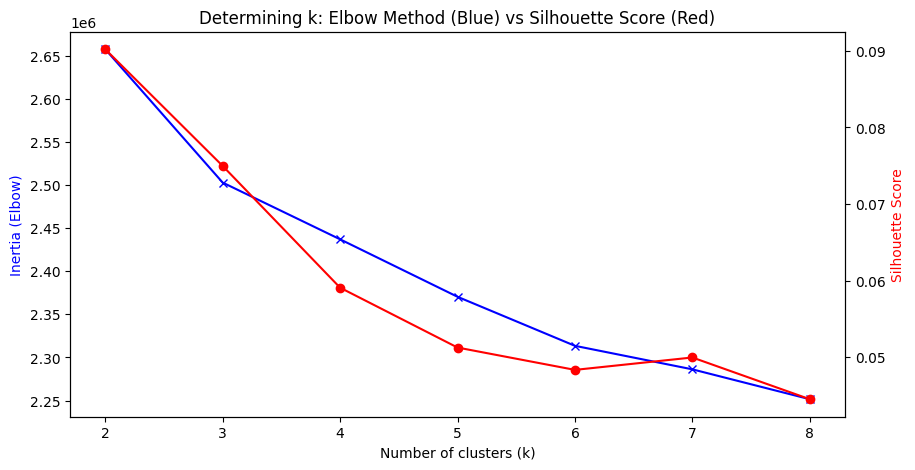

In [19]:

inertia = []
sil_scores = []
k_range = range(2, 9)

# We use a sample for the Silhouette score because calculating pairwise distance 
# for 1M rows to get the silhouette score would crash the RAM.
X_sample = df.sample(n=10000, random_state=42) if len(df) > 10000 else df

print("Finding optimal k...")
for k in k_range:
    # MiniBatchKMeans trains on 1M rows almost instantly
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=2048)
    
    # Fit on the entire DataFrame
    km.fit(df)
    inertia.append(km.inertia_)

    # Evaluate silhouette score on the sample
    sample_labels = km.predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, sample_labels))
    
    print(f"k={k} completed.")

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(k_range, inertia, 'bx-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 'ro-')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Determining k: Elbow Method (Blue) vs Silhouette Score (Red)')
plt.show()
# Pick k where the Silhouette Score (Red) is highest or has a local peak.

## Modeling: 50 Columns

### K-Means Clustering

In [21]:
X = df


kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=2048, n_init="auto")
kmeans_labels = kmeans.fit_predict(X)
print("K-Means training complete!")

c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


K-Means training complete!


#### K-Means Evaluation (Silhouette Score)

In [22]:
sample_size = 5000 # 5K
X_eval = df.sample(n=min(sample_size, len(df)), random_state=42)
eval_labels = kmeans.predict(X_eval)

score = silhouette_score(X_eval, eval_labels)
print(f"Final K-Means Silhouette Score: {score:.4f}")

print("\nCluster Distribution (Percentage):")
print(pd.Series(kmeans_labels).value_counts(normalize=True).sort_index() * 100)

Final K-Means Silhouette Score: 0.0459

Cluster Distribution (Percentage):
0    22.422762
1    21.641550
2    19.981137
3    17.376003
4    18.578548
Name: proportion, dtype: float64


### Hierarchical Clustering

In [56]:
sample_size = 10000
X_sample = X.sample(n=min(sample_size, len(X)), random_state=42)

hier = AgglomerativeClustering(n_clusters=5)
hier_sample_labels = hier.fit_predict(X_sample)

In [57]:
print("Assigning Hierarchical clusters to full dataset using KNN in batches...")
knn_hier = KNeighborsClassifier(n_neighbors=5)
knn_hier.fit(X_sample, hier_sample_labels)

# Predict the full 1 Million rows in memory-safe batches
hier_labels = []
batch_size = 10000
for i in range(0, len(X), batch_size):
    batch = X.iloc[i:i+batch_size]
    hier_labels.extend(knn_hier.predict(batch))
hier_labels = np.array(hier_labels)
print("Hierarchical assignment complete!\n")

Assigning Hierarchical clusters to full dataset using KNN in batches...
Hierarchical assignment complete!



#### Hierarchical Evaluation

In [58]:
eval_sample_size = 10000

# Randomly select indices for the evaluation sample
np.random.seed(42)
indices = np.random.choice(len(X), size=min(eval_sample_size, len(X)), replace=False)

# Get the sample data and corresponding predicted labels
X_eval = X.iloc[indices]
hier_labels_eval = hier_labels[indices]

# Calculate the score
hier_score = silhouette_score(X_eval, hier_labels_eval)
print("Hierarchical Score:", hier_score)

Hierarchical Score: 0.020509586


### DBSCAN

In [23]:
db = DBSCAN(eps=0.5, min_samples=10)
db_sample_labels = db.fit_predict(X_sample)

# Filter out noise points (-1) before training the KNN
valid_mask = db_sample_labels != -1
X_valid = X_sample.iloc[valid_mask]
y_valid = db_sample_labels[valid_mask]

In [24]:
print("Assigning DBSCAN clusters to full dataset using KNN in batches...")
dbscan_labels = []

# Ensure DBSCAN actually found distinct clusters (not just noise)
if len(set(y_valid)) > 1:
    knn_db = KNeighborsClassifier(n_neighbors=5)
    knn_db.fit(X_valid, y_valid)
    
    for i in range(0, len(X), batch_size):
        batch = X.iloc[i:i+batch_size]
        dbscan_labels.extend(knn_db.predict(batch))
    dbscan_labels = np.array(dbscan_labels)
    print("DBSCAN assignment complete!\n")
else:
    print("DBSCAN did not find enough valid clusters. All labels set to -1 (Noise).\n")
    dbscan_labels = np.full(len(X), -1)

Assigning DBSCAN clusters to full dataset using KNN in batches...
DBSCAN did not find enough valid clusters. All labels set to -1 (Noise).



#### DBSCAN Evaluation

In [25]:
eval_sample_size = 10000
np.random.seed(42)
indices = np.random.choice(len(X), size=min(eval_sample_size, len(X)), replace=False)

X_eval = X.iloc[indices]
db_labels_eval = dbscan_labels[indices] # Use the labels assigned via the KNN batch logic

mask = db_labels_eval != -1
X_eval_filtered = X_eval[mask]
labels_eval_filtered = db_labels_eval[mask]

# 3. Calculate score
if len(set(labels_eval_filtered)) > 1:
    db_score = silhouette_score(X_eval_filtered, labels_eval_filtered)
    print(f"DBSCAN Score (on {len(X_eval_filtered)} non-noise points):", db_score)
else:
    print("DBSCAN did not form valid clusters in the evaluation sample.")

DBSCAN did not form valid clusters in the evaluation sample.


## Modeling: 50 Columns with PCA (Dimension Reduction for the 50 Columns)

### Select the original 50 Big Five question columns


In [20]:
question_cols = (
    [f'EXT{i}' for i in range(1, 11)] +
    [f'EST{i}' for i in range(1, 11)] +
    [f'AGR{i}' for i in range(1, 11)] +
    [f'CSN{i}' for i in range(1, 11)] +
    [f'OPN{i}' for i in range(1, 11)]
)
X_50 = df[question_cols].copy()

### Scale first


In [21]:
scaler = StandardScaler()
X_50_scaled = scaler.fit_transform(X_50)

### PCA: keep 95% of variance


In [22]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_50_scaled)

### Convert to DataFrame


In [23]:
df_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i}' for i in range(1, X_pca.shape[1] + 1)]
)

print("Original shape:", X_50.shape)
print("PCA shape:", df_pca.shape)
print("Number of selected components:", pca.n_components_)
print("Explained variance ratio sum:", np.sum(pca.explained_variance_ratio_))

df_pca.head()

Original shape: (1007280, 50)
PCA shape: (1007280, 43)
Number of selected components: 43
Explained variance ratio sum: 0.9514230442180923


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41,PC42,PC43
0,-4.283953,-0.430954,2.098722,-1.157545,0.161609,0.668846,0.507899,-0.148959,-0.376857,0.667640,...,-0.127467,-0.073383,0.708448,-0.063000,0.258245,0.455596,0.080598,-0.005510,-0.558634,0.994299
1,0.427673,1.516876,-2.643099,1.610767,-2.401118,0.030839,-1.585515,0.320795,-1.196440,0.189727,...,-0.249391,0.204799,-1.211042,-0.141452,0.660156,-0.658872,-0.180924,0.473572,-0.366559,-0.002941
2,-0.547476,1.330222,-1.195779,-0.033541,-1.944430,1.876664,1.125262,0.433898,0.937819,0.107101,...,-0.003223,0.387628,-0.348152,0.505680,-0.051839,1.355510,-0.709836,-0.716773,-0.421008,-0.149417
3,0.947643,-0.175760,1.368063,-0.609904,-2.061317,0.864059,0.159510,-0.644629,-0.290228,-0.417426,...,-0.744181,-0.377338,-0.073443,-0.271192,0.111043,-0.573891,-1.065428,0.890691,0.222956,-0.411489
4,-4.068311,1.753616,-3.872366,-1.734758,-0.635137,-0.002876,-0.088089,-0.297761,-1.370132,-0.586273,...,0.138038,0.028937,0.908219,-0.195472,-0.439031,0.177015,-0.329838,1.625409,-0.436154,0.418593


In [33]:
sample_size = min(5000, len(X_50_scaled))
idx = np.random.choice(len(X_50_scaled), sample_size, replace=False)

X_before_sample = X_50_scaled[idx]
X_after_sample = X_pca[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_before_2d = tsne.fit_transform(X_before_sample)
X_after_2d = X_after_sample[:, :2]

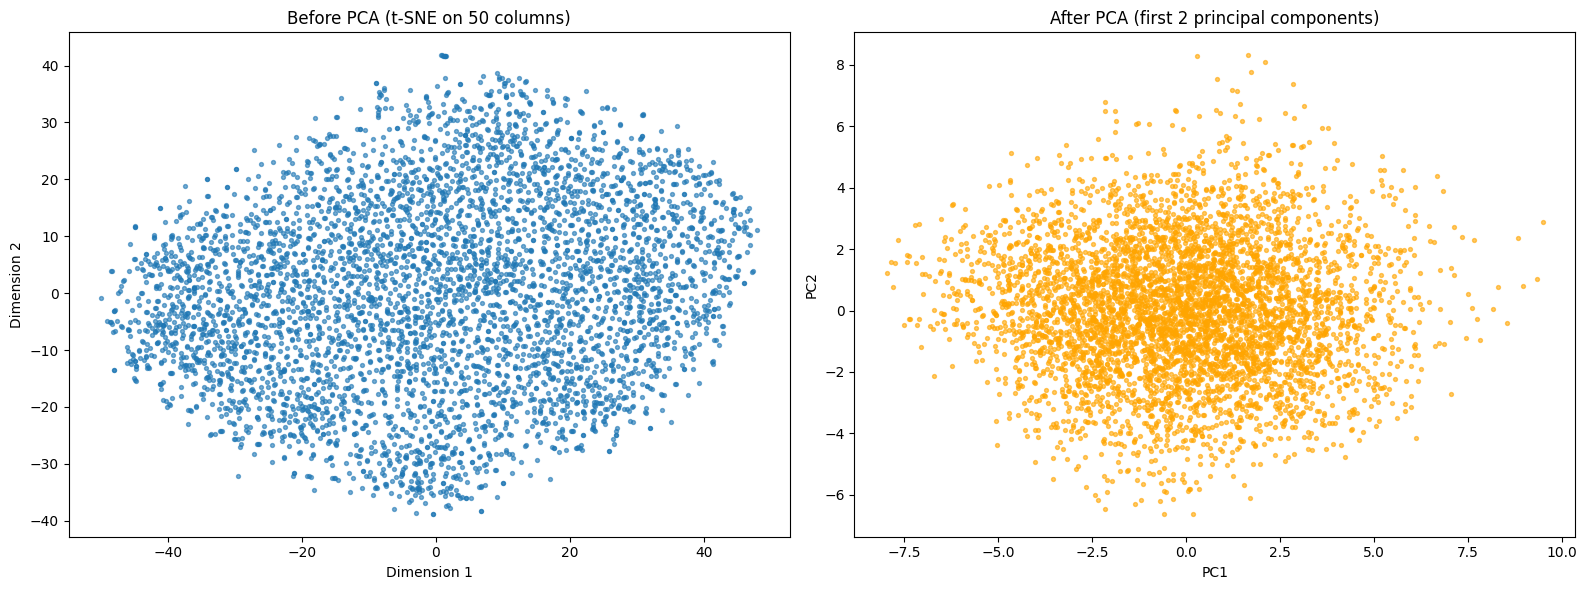

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_before_2d[:, 0], X_before_2d[:, 1], s=8, alpha=0.6)
axes[0].set_title('Before PCA (t-SNE on 50 columns)')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')

axes[1].scatter(X_after_2d[:, 0], X_after_2d[:, 1], s=8, alpha=0.6, color='orange')
axes[1].set_title('After PCA (first 2 principal components)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

### K-Means Clustering

In [35]:
X = df_pca


kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=2048, n_init="auto")
kmeans_labels = kmeans.fit_predict(X)
print("K-Means training complete!")

c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


K-Means training complete!


#### K-Means Evaluation (Silhouette Score)

In [38]:
sample_size = 5000 # 5K
X_eval = df_pca.sample(n=min(sample_size, len(df_pca)), random_state=42)
eval_labels = kmeans.predict(X_eval)

score = silhouette_score(X_eval, eval_labels)
print(f"Final K-Means Silhouette Score: {score:.4f}")

print("\nCluster Distribution (Percentage):")
print(pd.Series(kmeans_labels).value_counts(normalize=True).sort_index() * 100)

Final K-Means Silhouette Score: 0.0561

Cluster Distribution (Percentage):
0    13.383766
1    20.307065
2    25.206298
3    21.894508
4    19.208363
Name: proportion, dtype: float64


### Hierarchical Clustering

In [39]:
sample_size = 10000
X_sample = X.sample(n=min(sample_size, len(X)), random_state=42)

hier = AgglomerativeClustering(n_clusters=5)
hier_sample_labels = hier.fit_predict(X_sample)

In [40]:
print("Assigning Hierarchical clusters to full dataset using KNN in batches...")
knn_hier = KNeighborsClassifier(n_neighbors=5)
knn_hier.fit(X_sample, hier_sample_labels)

# Predict the full 1 Million rows in memory-safe batches
hier_labels = []
batch_size = 10000
for i in range(0, len(X), batch_size):
    batch = X.iloc[i:i+batch_size]
    hier_labels.extend(knn_hier.predict(batch))
hier_labels = np.array(hier_labels)
print("Hierarchical assignment complete!\n")

Assigning Hierarchical clusters to full dataset using KNN in batches...
Hierarchical assignment complete!



#### Hierarchical Evaluation

In [41]:
eval_sample_size = 10000

# Randomly select indices for the evaluation sample
np.random.seed(42)
indices = np.random.choice(len(X), size=min(eval_sample_size, len(X)), replace=False)

# Get the sample data and corresponding predicted labels
X_eval = X.iloc[indices]
hier_labels_eval = hier_labels[indices]

# Calculate the score
hier_score = silhouette_score(X_eval, hier_labels_eval)
print("Hierarchical Score:", hier_score)

Hierarchical Score: 0.04304554


### DBSCAN

In [42]:
db = DBSCAN(eps=0.5, min_samples=10)
db_sample_labels = db.fit_predict(X_sample)

# Filter out noise points (-1) before training the KNN
valid_mask = db_sample_labels != -1
X_valid = X_sample.iloc[valid_mask]
y_valid = db_sample_labels[valid_mask]

In [43]:
print("Assigning DBSCAN clusters to full dataset using KNN in batches...")
dbscan_labels = []

# Ensure DBSCAN actually found distinct clusters (not just noise)
if len(set(y_valid)) > 1:
    knn_db = KNeighborsClassifier(n_neighbors=5)
    knn_db.fit(X_valid, y_valid)
    
    for i in range(0, len(X), batch_size):
        batch = X.iloc[i:i+batch_size]
        dbscan_labels.extend(knn_db.predict(batch))
    dbscan_labels = np.array(dbscan_labels)
    print("DBSCAN assignment complete!\n")
else:
    print("DBSCAN did not find enough valid clusters. All labels set to -1 (Noise).\n")
    dbscan_labels = np.full(len(X), -1)

Assigning DBSCAN clusters to full dataset using KNN in batches...
DBSCAN did not find enough valid clusters. All labels set to -1 (Noise).



#### DBSCAN Evaluation

In [44]:
eval_sample_size = 10000
np.random.seed(42)
indices = np.random.choice(len(X), size=min(eval_sample_size, len(X)), replace=False)

X_eval = X.iloc[indices]
db_labels_eval = dbscan_labels[indices] # Use the labels assigned via the KNN batch logic

mask = db_labels_eval != -1
X_eval_filtered = X_eval[mask]
labels_eval_filtered = db_labels_eval[mask]

# 3. Calculate score
if len(set(labels_eval_filtered)) > 1:
    db_score = silhouette_score(X_eval_filtered, labels_eval_filtered)
    print(f"DBSCAN Score (on {len(X_eval_filtered)} non-noise points):", db_score)
else:
    print("DBSCAN did not form valid clusters in the evaluation sample.")

DBSCAN did not form valid clusters in the evaluation sample.


## Modeling: 5 Columns (Average of each cluster Questions)

### Convert the 50 Big Five item columns into 5 main score columns

In [16]:
df_scores = pd.DataFrame({
    'EXT_score': df[[f'EXT{i}' for i in range(1, 11)]].mean(axis=1),
    'EST_score': df[[f'EST{i}' for i in range(1, 11)]].mean(axis=1),
    'AGR_score': df[[f'AGR{i}' for i in range(1, 11)]].mean(axis=1),
    'CSN_score': df[[f'CSN{i}' for i in range(1, 11)]].mean(axis=1),
    'OPN_score': df[[f'OPN{i}' for i in range(1, 11)]].mean(axis=1)
})

df_scores.head()

,EXT_score,EST_score,AGR_score,CSN_score,OPN_score
0,4.6,2.4,3.9,3.2,4.5
1,2.0,2.5,4.4,3.7,3.5
2,2.5,2.6,4.2,3.4,4.1
3,2.6,2.9,3.8,2.5,3.9
4,2.9,1.9,4.6,4.8,4.8


### K-Means Clustering

In [17]:
X = df_scores


kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=2048, n_init="auto")
kmeans_labels = kmeans.fit_predict(X)
print("K-Means training complete!")

c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


K-Means training complete!


#### K-Means Evaluation (Silhouette Score)

In [18]:
sample_size = 5000 # 5K
X_eval = df_scores.sample(n=min(sample_size, len(df_scores)), random_state=42)
eval_labels = kmeans.predict(X_eval)

score = silhouette_score(X_eval, eval_labels)
print(f"Final K-Means Silhouette Score: {score:.4f}")

print("\nCluster Distribution (Percentage):")
print(pd.Series(kmeans_labels).value_counts(normalize=True).sort_index() * 100)

Final K-Means Silhouette Score: 0.1523

Cluster Distribution (Percentage):
0    16.086689
1    23.230085
2    21.671134
3    19.867266
4    19.144826
Name: proportion, dtype: float64


### Hierarchical Clustering

In [19]:
sample_size = 10000
X_sample = X.sample(n=min(sample_size, len(X)), random_state=42)

hier = AgglomerativeClustering(n_clusters=5)
hier_sample_labels = hier.fit_predict(X_sample)

In [20]:
print("Assigning Hierarchical clusters to full dataset using KNN in batches...")
knn_hier = KNeighborsClassifier(n_neighbors=5)
knn_hier.fit(X_sample, hier_sample_labels)

# Predict the full 1 Million rows in memory-safe batches
hier_labels = []
batch_size = 10000
for i in range(0, len(X), batch_size):
    batch = X.iloc[i:i+batch_size]
    hier_labels.extend(knn_hier.predict(batch))
hier_labels = np.array(hier_labels)
print("Hierarchical assignment complete!\n")

Assigning Hierarchical clusters to full dataset using KNN in batches...
Hierarchical assignment complete!



#### Hierarchical Evaluation

In [21]:
eval_sample_size = 10000

# Randomly select indices for the evaluation sample
np.random.seed(42)
indices = np.random.choice(len(X), size=min(eval_sample_size, len(X)), replace=False)

# Get the sample data and corresponding predicted labels
X_eval = X.iloc[indices]
hier_labels_eval = hier_labels[indices]

# Calculate the score
hier_score = silhouette_score(X_eval, hier_labels_eval)
print("Hierarchical Score:", hier_score)

Hierarchical Score: 0.08967896


### DBSCAN

In [22]:
db = DBSCAN(eps=0.5, min_samples=10)
db_sample_labels = db.fit_predict(X_sample)

# Filter out noise points (-1) before training the KNN
valid_mask = db_sample_labels != -1
X_valid = X_sample.iloc[valid_mask]
y_valid = db_sample_labels[valid_mask]

In [23]:
print("Assigning DBSCAN clusters to full dataset using KNN in batches...")
dbscan_labels = []

# Ensure DBSCAN actually found distinct clusters (not just noise)
if len(set(y_valid)) > 1:
    knn_db = KNeighborsClassifier(n_neighbors=5)
    knn_db.fit(X_valid, y_valid)
    
    for i in range(0, len(X), batch_size):
        batch = X.iloc[i:i+batch_size]
        dbscan_labels.extend(knn_db.predict(batch))
    dbscan_labels = np.array(dbscan_labels)
    print("DBSCAN assignment complete!\n")
else:
    print("DBSCAN did not find enough valid clusters. All labels set to -1 (Noise).\n")
    dbscan_labels = np.full(len(X), -1)

Assigning DBSCAN clusters to full dataset using KNN in batches...
DBSCAN assignment complete!



#### DBSCAN Evaluation

In [24]:
eval_sample_size = 10000
np.random.seed(42)
indices = np.random.choice(len(X), size=min(eval_sample_size, len(X)), replace=False)

X_eval = X.iloc[indices]
db_labels_eval = dbscan_labels[indices] # Use the labels assigned via the KNN batch logic

mask = db_labels_eval != -1
X_eval_filtered = X_eval[mask]
labels_eval_filtered = db_labels_eval[mask]

# 3. Calculate score
if len(set(labels_eval_filtered)) > 1:
    db_score = silhouette_score(X_eval_filtered, labels_eval_filtered)
    print(f"DBSCAN Score (on {len(X_eval_filtered)} non-noise points):", db_score)
else:
    print("DBSCAN did not form valid clusters in the evaluation sample.")

DBSCAN Score (on 10000 non-noise points): 0.070389345


## GMM: Gaussian Mixture on 5 scores

In [28]:
from sklearn.mixture import GaussianMixture

In [29]:
trait_cols = ['EXT_score', 'EST_score', 'AGR_score', 'CSN_score', 'OPN_score']
X = df_scores[trait_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_range = range(2, 9)
results = []

In [30]:
gmm_best = GaussianMixture(
    n_components=int(5),
    covariance_type='diag',
    random_state=42,
    n_init=5,
    max_iter=150
)
gmm_best.fit(X_scaled)

gmm_labels = gmm_best.predict(X_scaled)         
gmm_probs  = gmm_best.predict_proba(X_scaled)    


In [31]:
df_scores['gmm_cluster'] = gmm_labels
df_scores['gmm_max_prob'] = gmm_probs.max(axis=1)

print("\nCluster counts:")
print(df_scores['gmm_cluster'].value_counts().sort_index())


Cluster counts:
gmm_cluster
0    179394
1    269635
2    230179
3    199009
4    129063
Name: count, dtype: int64


In [32]:
# 8) وصف سريع للـ clusters
cluster_profile = df_scores.groupby('gmm_cluster')[trait_cols].mean()
print("\nCluster profile (mean trait scores per cluster):")
display(cluster_profile)


Cluster profile (mean trait scores per cluster):


,EXT_score,EST_score,AGR_score,CSN_score,OPN_score
gmm_cluster,,,,,
0,3.839288,3.124702,4.100287,2.834490,4.136462
1,3.422087,2.489475,4.242571,4.023756,4.044842
2,2.591740,3.196782,3.402649,3.171174,3.070720
3,2.280631,3.760130,3.958395,3.163389,4.086112
4,2.521569,2.861678,2.637627,3.320018,4.292166


## Final Comparison

In [68]:
eval_sample_size = 10000
np.random.seed(42)

X_base = df  # 50 columns (بعد MinMaxScaler اللي عملته قبل كده)
indices = np.random.choice(len(X_base), size=min(eval_sample_size, len(X_base)), replace=False)

In [69]:
X_50= df.iloc[indices]           
X_50_pca= df_pca.iloc[indices]        
X_5_scores= df_scores.iloc[indices]      

results = []

In [70]:
def eval_representation(name, X_rep, labels_full):
    """
    X_rep: subset من الـ features مطابق للـ indices
    labels_full: labels لكل الداتا (بنقصّها بنفس indices)
    """
    labels_sample = labels_full[indices]
    # في GMM مفيش -1, لكن لو في موديل بيطلع -1 (زي DBSCAN) هنفلتره
    mask = labels_sample != -1

    if len(set(labels_sample[mask])) > 1:
        s_score = silhouette_score(X_rep[mask], labels_sample[mask])
        db_score = davies_bouldin_score(X_rep[mask], labels_sample[mask])
        return [name, s_score, db_score]
    else:
        return [name, None, None]

In [71]:
kmeans_50 = MiniBatchKMeans(
    n_clusters=5,
    random_state=42,
    batch_size=2048,
    n_init=5
)
kmeans_50.fit(df)  # fit على كل الداتا
kmeans_50_labels = kmeans_50.labels_
results.append(eval_representation("KMeans_50_cols", X_50.values, kmeans_50_labels))

c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


In [72]:
kmeans_pca = MiniBatchKMeans(
    n_clusters=5,
    random_state=42,
    batch_size=2048,
    n_init=5
)
kmeans_pca.fit(df_pca)
kmeans_pca_labels = kmeans_pca.labels_
results.append(eval_representation("KMeans_50_PCA", X_50_pca.values, kmeans_pca_labels))

c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


In [73]:
kmeans_5 = MiniBatchKMeans(
    n_clusters=5,
    random_state=42,
    batch_size=2048,
    n_init=5
)
kmeans_5.fit(df_scores[['EXT_score','EST_score','AGR_score','CSN_score','OPN_score']])
kmeans_5_labels = kmeans_5.labels_
results.append(eval_representation("KMeans_5_scores", X_5_scores[['EXT_score','EST_score','AGR_score','CSN_score','OPN_score']].values, kmeans_5_labels))

c:\Users\AhmedHazem\anaconda3\envs\tf_gpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1966: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 4096 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(


In [74]:
results.append(
    eval_representation(
        "GMM_5_scores",
        X_5_scores[['EXT_score','EST_score','AGR_score','CSN_score','OPN_score']].values,
        gmm_labels
    )
)

In [75]:
df_final_results = pd.DataFrame(
    results,
    columns=["Representation / Model", "Silhouette Score", "Davies-Bouldin Score"]
)

print("\nFinal Comparison (50 vs PCA vs 5-scores vs GMM):")
display(df_final_results)


Final Comparison (50 vs PCA vs 5-scores vs GMM):


,Representation / Model,Silhouette Score,Davies-Bouldin Score
0,KMeans_50_cols,0.054460,2.990734
1,KMeans_50_PCA,0.049697,3.158247
2,KMeans_5_scores,0.144566,1.667034
3,GMM_5_scores,0.133469,1.813760


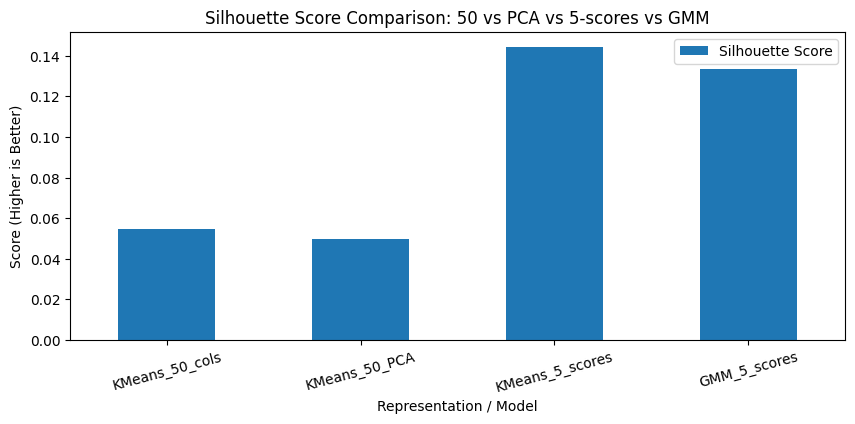

In [76]:
df_final_results.set_index("Representation / Model")[["Silhouette Score"]].plot(
    kind='bar', figsize=(10, 4), rot=15
)
plt.title("Silhouette Score Comparison: 50 vs PCA vs 5-scores vs GMM")
plt.ylabel("Score (Higher is Better)")
plt.show()

In [78]:
for c in range(5):
    print(f"\n=== Cluster {c} samples ===")
    display(
        df_scores[df_scores['gmm_cluster'] == c]
        [ ['EXT_score','EST_score','AGR_score','CSN_score','OPN_score','gmm_max_prob'] ]
        .head(5)
    )


=== Cluster 0 samples ===


,EXT_score,EST_score,AGR_score,CSN_score,OPN_score,gmm_max_prob
0,4.6,2.4,3.9,3.2,4.5,0.674112
6,3.5,3.0,4.1,3.3,4.3,0.564238
8,3.2,3.0,4.5,3.1,4.5,0.576680
11,4.0,4.6,3.9,3.6,4.3,0.764589
12,4.4,2.4,4.8,2.2,4.9,0.986656



=== Cluster 1 samples ===


,EXT_score,EST_score,AGR_score,CSN_score,OPN_score,gmm_max_prob
1,2.0,2.5,4.4,3.7,3.5,0.532711
2,2.5,2.6,4.2,3.4,4.1,0.509268
4,2.9,1.9,4.6,4.8,4.8,0.986658
5,3.2,2.2,3.8,3.7,4.4,0.745250
7,4.2,1.6,3.8,4.5,4.3,0.955424



=== Cluster 2 samples ===


,EXT_score,EST_score,AGR_score,CSN_score,OPN_score,gmm_max_prob
17,4.1,2.0,4.1,2.9,2.8,0.437572
19,4.4,4.2,3.7,4.5,3.0,0.471504
20,2.5,4.2,3.5,3.7,3.4,0.483102
21,2.9,3.4,3.6,2.9,2.3,0.989799
22,1.9,2.4,4.3,3.8,3.1,0.571551



=== Cluster 3 samples ===


,EXT_score,EST_score,AGR_score,CSN_score,OPN_score,gmm_max_prob
3,2.6,2.9,3.8,2.5,3.9,0.522745
10,2.9,3.9,3.7,2.4,5.0,0.608694
14,1.6,4.0,4.4,3.3,4.0,0.914501
15,3.1,3.7,3.4,3.5,4.2,0.468098
16,2.0,3.7,3.4,2.8,3.8,0.645895



=== Cluster 4 samples ===


,EXT_score,EST_score,AGR_score,CSN_score,OPN_score,gmm_max_prob
9,2.2,3.1,1.9,1.7,3.5,0.671738
13,1.0,4.4,2.6,3.9,4.2,0.877397
27,1.3,2.3,2.5,3.0,4.1,0.914853
37,2.8,2.3,3.0,2.5,4.9,0.866796
69,2.0,3.9,3.0,3.6,4.6,0.520355


## Visualization

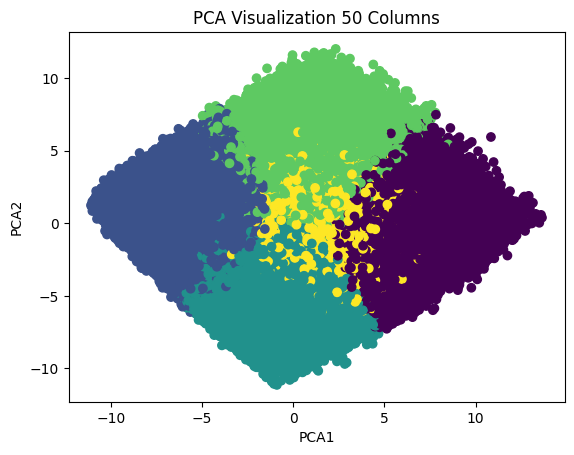

In [87]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(df)

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("PCA Visualization 50 Columns")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

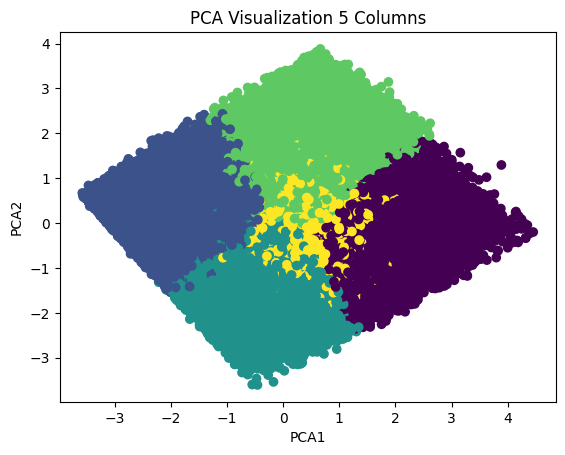

In [95]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(df_scores)

plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title("PCA Visualization 5 Columns")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(df)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=5)
plt.title("t-SNE Visualization")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

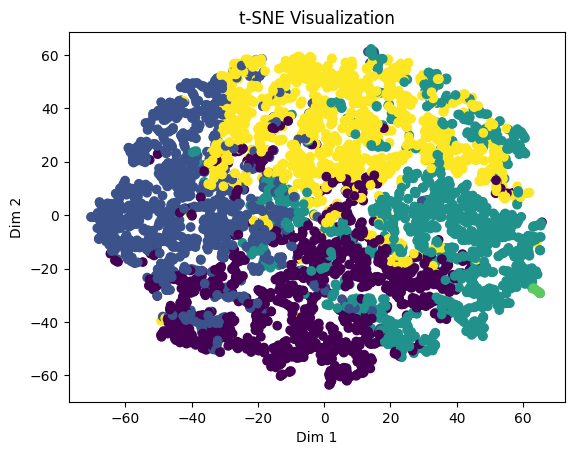

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(df_scores)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=5)
plt.title("t-SNE Visualization")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

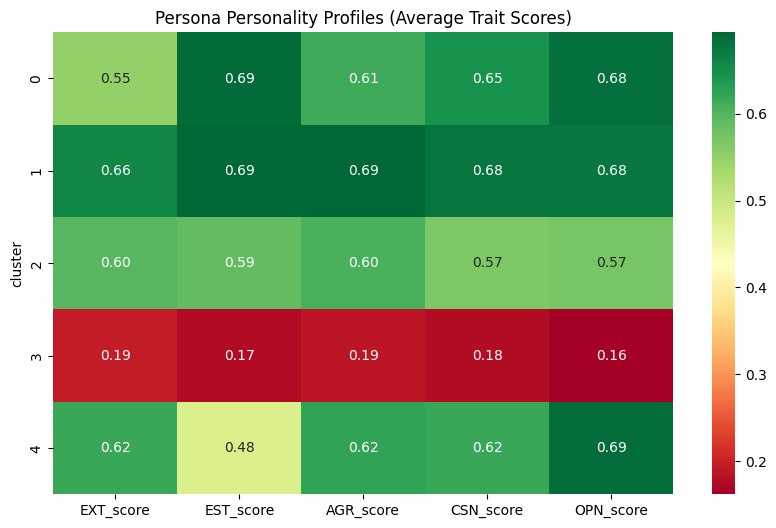

In [ ]:
# Map labels back to scores
df_results = df_scores.copy()
df_results['cluster'] = kmeans_labels

# Calculate average traits for each persona
cluster_profiles = df_results.groupby('cluster').mean()

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Persona Personality Profiles (Average Trait Scores)")
plt.show()

## Save Models

In [33]:
import joblib

# Save the K-Means model (from the latest successful training)
joblib.dump(kmeans, 'kmeans_5_scores_model.joblib')
print("K-Means model saved as 'kmeans_model.joblib'")

# Save the Hierarchical Clustering model
joblib.dump(hier, 'hierarchical_model.joblib')
print("Hierarchical Clustering model saved as 'hierarchical_model.joblib'")

# Save the GMM model
joblib.dump(gmm_best, 'gmm.joblib')
print("GMM model saved as 'gmm.joblib'")

K-Means model saved as 'kmeans_model.joblib'
Hierarchical Clustering model saved as 'hierarchical_model.joblib'
GMM model saved as 'gmm.joblib'
